# Pipeline Đếm Hạt Gạo

Notebook này dùng trực tiếp code trong `src/`. Toàn bộ tham số lấy từ `DEFAULT_CONFIG`. Sau khi sửa `src/config.py`, hãy chạy lại cell setup để notebook reload code mới trước khi chạy các cell xử lý và ghi log.


## 0. Import code từ `src`

Cell này thêm thư mục `src/` vào `sys.path`, sau đó import các hàm xử lý chính. Notebook không định nghĩa lại pipeline để tránh lệch logic hoặc lệch tham số.


In [41]:
from pathlib import Path
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from skimage import color, measure

def find_project_root(start):
    candidates = [start, *start.parents, start / "Computer-Vision"]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "Dataset").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root chứa src/ và Dataset/")


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config as config_module
import main as main_module
import parameter_log as parameter_log_module
import preprocess as preprocess_module
import segment as segment_module
import utils as utils_module
import visualize as visualize_module
import watershed_count as watershed_count_module

# Reload để notebook nhận tham số/code mới sau khi sửa file trong src/.
config_module = importlib.reload(config_module)
watershed_count_module = importlib.reload(watershed_count_module)
preprocess_module = importlib.reload(preprocess_module)
segment_module = importlib.reload(segment_module)
utils_module = importlib.reload(utils_module)
visualize_module = importlib.reload(visualize_module)
parameter_log_module = importlib.reload(parameter_log_module)
main_module = importlib.reload(main_module)

from config import DEFAULT_CONFIG

CONFIG = DEFAULT_CONFIG
DATASET_DIR = CONFIG.dataset_dir
OUTPUT_DIR = CONFIG.output_dir
LOG_DIR = CONFIG.log_dir

run_all_images = main_module.run_all_images
correct_illumination = preprocess_module.correct_illumination
correct_illumination_fourier = preprocess_module.correct_illumination_fourier
denoise_image = preprocess_module.denoise_image
enhance_contrast = preprocess_module.enhance_contrast
preprocess_image = preprocess_module.preprocess_image
suppress_stripes_fourier = preprocess_module.suppress_stripes_fourier
to_grayscale = preprocess_module.to_grayscale
clean_mask = segment_module.clean_mask
segment_grains = segment_module.segment_grains
threshold_grains = segment_module.threshold_grains
list_image_files = utils_module.list_image_files
read_image = utils_module.read_image
contour_overlay = visualize_module.contour_overlay
filter_grain_regions = watershed_count_module.filter_grain_regions
separate_and_count = watershed_count_module.separate_and_count
watershed_separation = watershed_count_module.watershed_separation

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 11

print("Project root:", PROJECT_ROOT)
print("Dataset dir:", DATASET_DIR)
print("Output dir:", OUTPUT_DIR)
print("Log dir:", LOG_DIR)
print("Config:", CONFIG)


Project root: c:\Users\Admin\Desktop\Cao học Bách Khoa\Thị giác máy tính\Assigment\Computer-Vision
Dataset dir: Dataset
Output dir: output
Log dir: logs
Config: PipelineConfig(dataset_dir=WindowsPath('Dataset'), output_dir=WindowsPath('output'), log_dir=WindowsPath('logs'), median_kernel_size=5, fourier_cutoff=5, fourier_low_gain=0.0, fourier_high_gain=1.3, fourier_stripe_min_frequency=8, fourier_stripe_max_frequency=32, fourier_stripe_top_k=4, fourier_stripe_radius=1, fourier_stripe_strength=1.0, clahe_clip_limit=1.5, clahe_tile_grid_size=(6, 6), morphology_kernel_size=3, mask_dilation_iterations=0, adaptive_block_size=31, adaptive_c=-8, otsu_min_foreground_ratio=0.12, otsu_max_foreground_ratio=0.5, min_grain_area=100, max_grain_area=8000, min_aspect_ratio=1.2, max_aspect_ratio=10.0, min_solidity=0.5, min_eccentricity=0.7, min_peak_distance=13, watershed_split_area_factor=1.3)


## 1. Hàm tiện ích hiển thị

Các hàm dưới đây chỉ dùng để in thống kê và hiển thị ảnh trong notebook. Chúng không thay đổi pipeline xử lý ảnh.


In [42]:
def image_summary(name, image):
    array = np.asarray(image)
    return {
        "name": name,
        "shape": array.shape,
        "dtype": str(array.dtype),
        "min": float(array.min()),
        "max": float(array.max()),
        "mean": float(array.mean()),
        "std": float(array.std()),
    }


def mask_summary(name, mask):
    labels = measure.label(mask.astype(bool))
    return {
        "name": name,
        "foreground_pixels": int(mask.sum()),
        "foreground_ratio": float(mask.mean()),
        "connected_components": int(labels.max()),
    }


def label_summary(name, labels):
    return {
        "name": name,
        "label_count": int(labels.max()),
        "labeled_pixels": int((labels > 0).sum()),
    }


def print_image_result(name, image):
    print(f"[{name}]")
    display(pd.DataFrame([image_summary(name, image)]))


def print_mask_result(name, mask):
    print(f"[{name}]")
    display(pd.DataFrame([mask_summary(name, mask)]))


def print_label_result(name, labels):
    print(f"[{name}]")
    display(pd.DataFrame([label_summary(name, labels)]))


def show_images(items, cols=3):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, (title, image) in zip(axes, items):
        axis.set_title(title)
        if image.ndim == 2:
            axis.imshow(image, cmap="gray")
        else:
            axis.imshow(image)
        axis.axis("off")

    for axis in axes[len(items):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


def show_histogram(title, image):
    plt.figure(figsize=(8, 4))
    plt.hist(np.asarray(image).ravel(), bins=256, color="steelblue")
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.show()

## 2. Đọc ảnh và kiểm tra dataset

Sử dụng `list_image_files` và `read_image` từ `src/utils.py`. Sau khi đọc ảnh, notebook in thống kê và hiển thị toàn bộ ảnh đầu vào.


[list_image_files]
Tìm thấy 4 ảnh
0 gạo_bình_thường.png
1 gạo_nhiễu_muối_tiêu.png
2 gạo_nền_không_đều.png
3 gạo_tương_phản_thấp.png


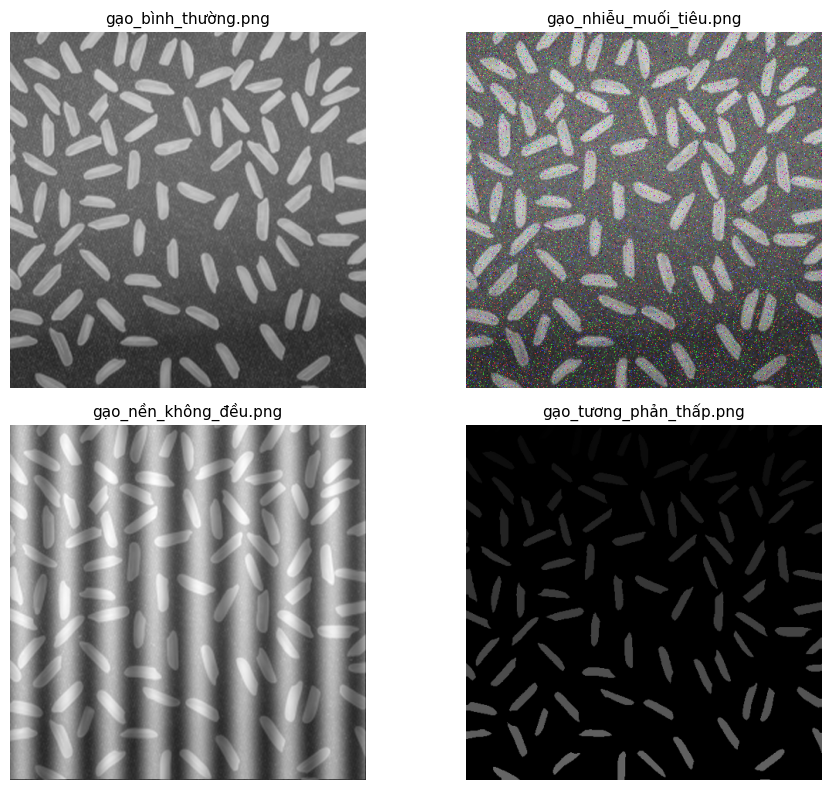

[read_image - sample image]


,name,shape,dtype,min,max,mean,std
0,read_image - sample image,"(461, 461, 3)",uint8,34.0,211.0,110.776563,42.640393


Ảnh mẫu: gạo_bình_thường.png (461, 461, 3)


In [43]:
image_paths = list_image_files(DATASET_DIR)
print("[list_image_files]")
print(f"Tìm thấy {len(image_paths)} ảnh")
for index, path in enumerate(image_paths):
    print(index, path.name)

input_images = [(path.name, read_image(path)) for path in image_paths]
show_images(input_images, cols=2)

SAMPLE_NAME = "gạo_bình_thường.png"
sample_path = next(path for path in image_paths if path.name == SAMPLE_NAME)
sample_image = read_image(sample_path)
print_image_result("read_image - sample image", sample_image)
print("Ảnh mẫu:", sample_path.name, sample_image.shape)

## 3. Tiền xử lý ảnh

Các bước tiền xử lý đều gọi trực tiếp từ `src/preprocess.py`: grayscale, median blur, hiệu chỉnh nền và CLAHE.


Pipeline tiền xử lý: median -> Fourier homomorphic -> Fourier notch -> CLAHE
gạo_bình_thường.png correct_illumination equals Fourier + notch: True
gạo_bình_thường.png preprocess_image equals step-by-step enhanced: True
gạo_nhiễu_muối_tiêu.png correct_illumination equals Fourier + notch: True
gạo_nhiễu_muối_tiêu.png preprocess_image equals step-by-step enhanced: True
gạo_nền_không_đều.png correct_illumination equals Fourier + notch: True
gạo_nền_không_đều.png preprocess_image equals step-by-step enhanced: True
gạo_tương_phản_thấp.png correct_illumination equals Fourier + notch: True
gạo_tương_phản_thấp.png preprocess_image equals step-by-step enhanced: True


,image_name,step,shape,dtype,min,max,mean,std
0,gạo_bình_thường.png,input_image,"(461, 461, 3)",uint8,34.0,211.0,110.776563,42.640393
1,gạo_bình_thường.png,to_grayscale,"(461, 461)",uint8,34.0,211.0,110.776563,42.640393
2,gạo_bình_thường.png,denoise_image,"(461, 461)",uint8,43.0,204.0,110.419973,41.951439
3,gạo_bình_thường.png,correct_illumination_fourier,"(461, 461)",uint8,0.0,254.0,66.664711,42.524529
4,gạo_bình_thường.png,suppress_stripes_fourier,"(461, 461)",uint8,0.0,255.0,66.157194,42.332761
5,gạo_bình_thường.png,correct_illumination,"(461, 461)",uint8,0.0,255.0,66.157194,42.332761
6,gạo_bình_thường.png,enhance_contrast,"(461, 461)",uint8,1.0,255.0,81.623623,52.760323
7,gạo_bình_thường.png,preprocess_image,"(461, 461)",uint8,1.0,255.0,81.623623,52.760323
8,gạo_nhiễu_muối_tiêu.png,input_image,"(461, 461, 3)",uint8,0.0,255.0,111.824916,51.982189
9,gạo_nhiễu_muối_tiêu.png,to_grayscale,"(461, 461)",uint8,0.0,255.0,111.820997,45.785216


[input_image] toàn bộ ảnh


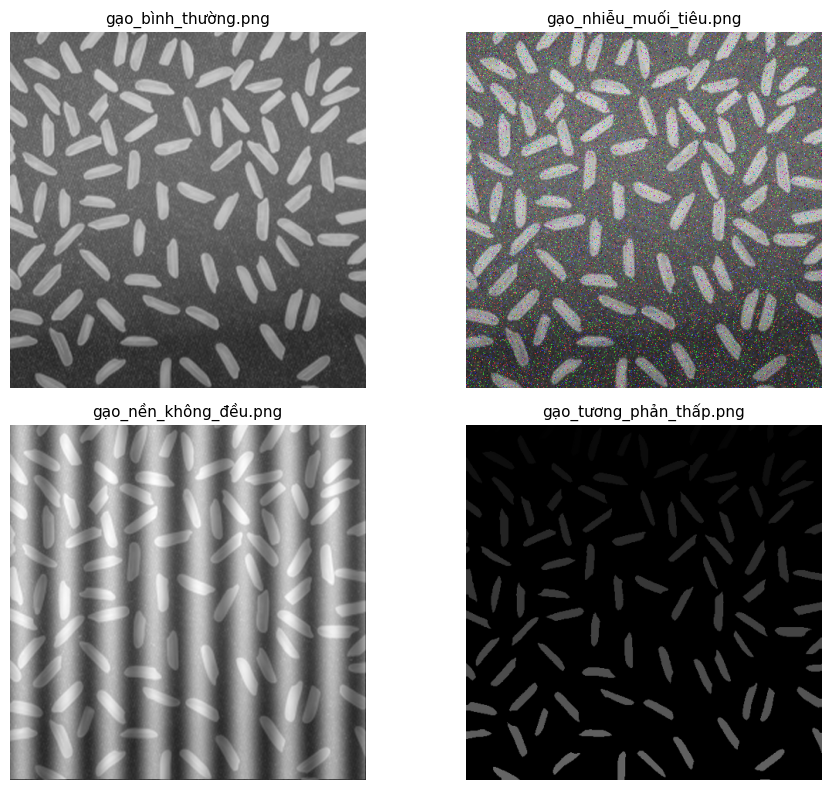

[to_grayscale] toàn bộ ảnh


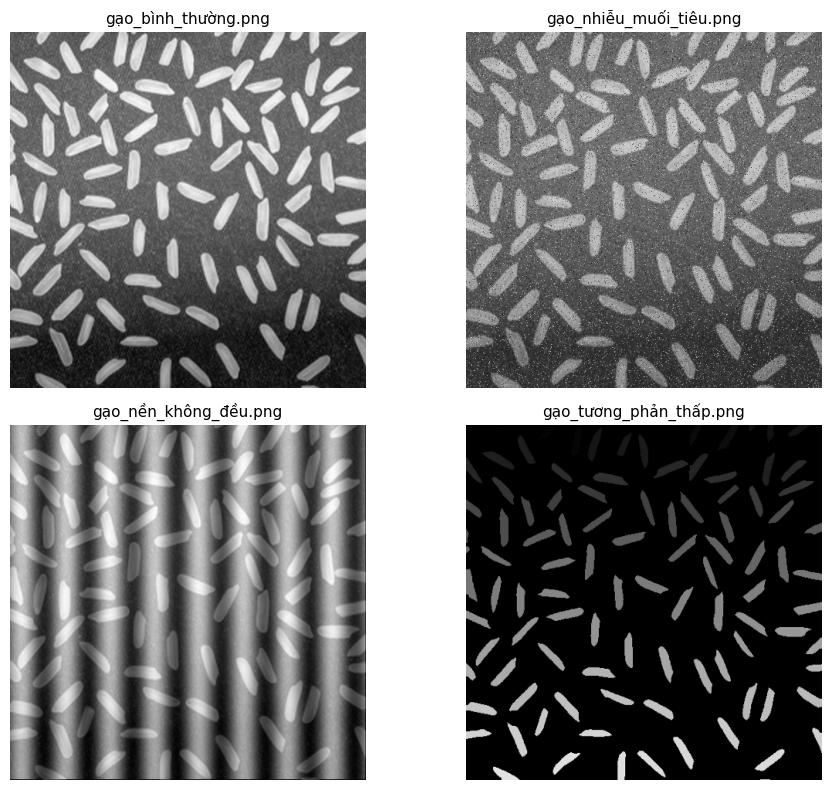

[denoise_image] toàn bộ ảnh


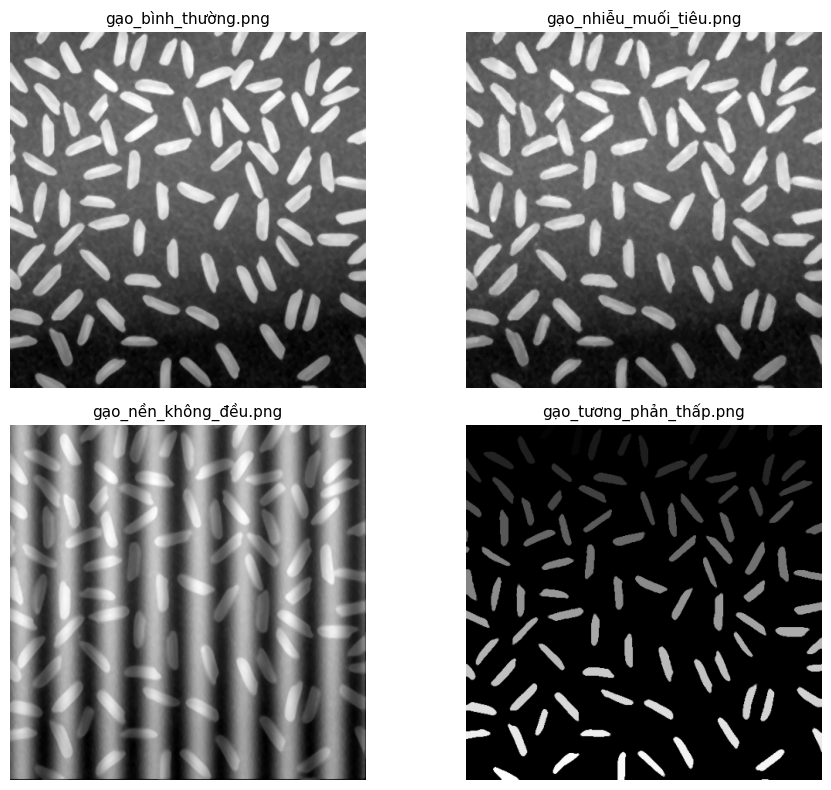

[correct_illumination_fourier] toàn bộ ảnh


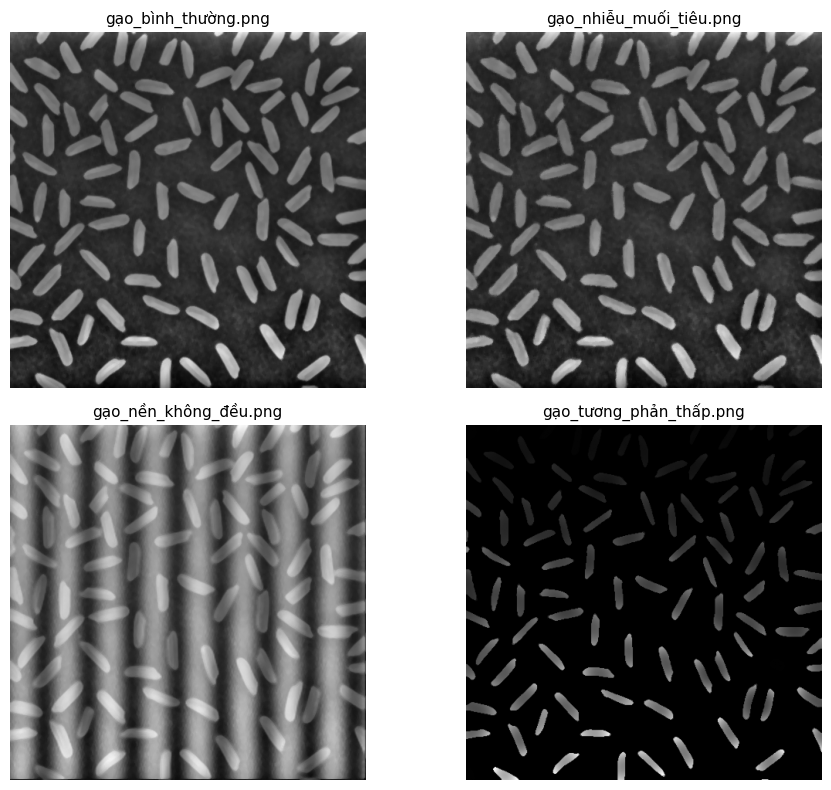

[suppress_stripes_fourier] toàn bộ ảnh


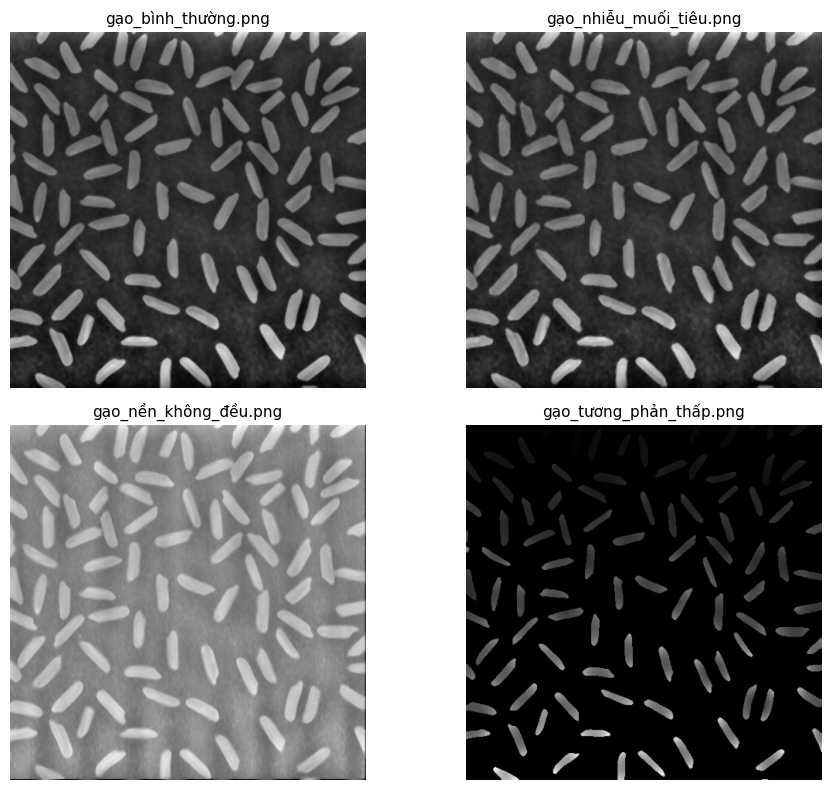

[correct_illumination] toàn bộ ảnh


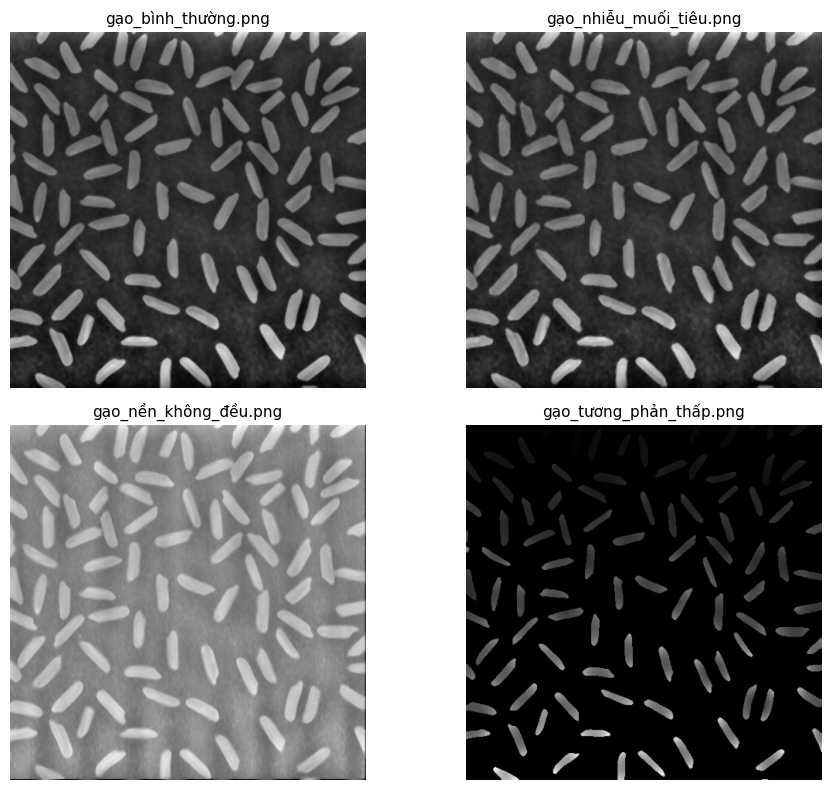

[enhance_contrast] toàn bộ ảnh


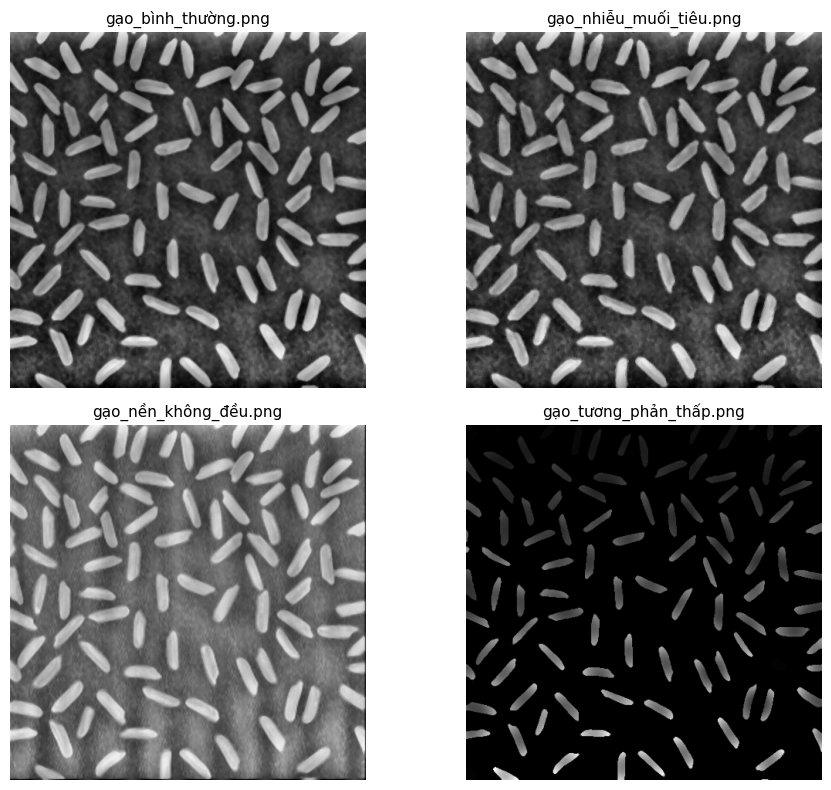

[preprocess_image] toàn bộ ảnh


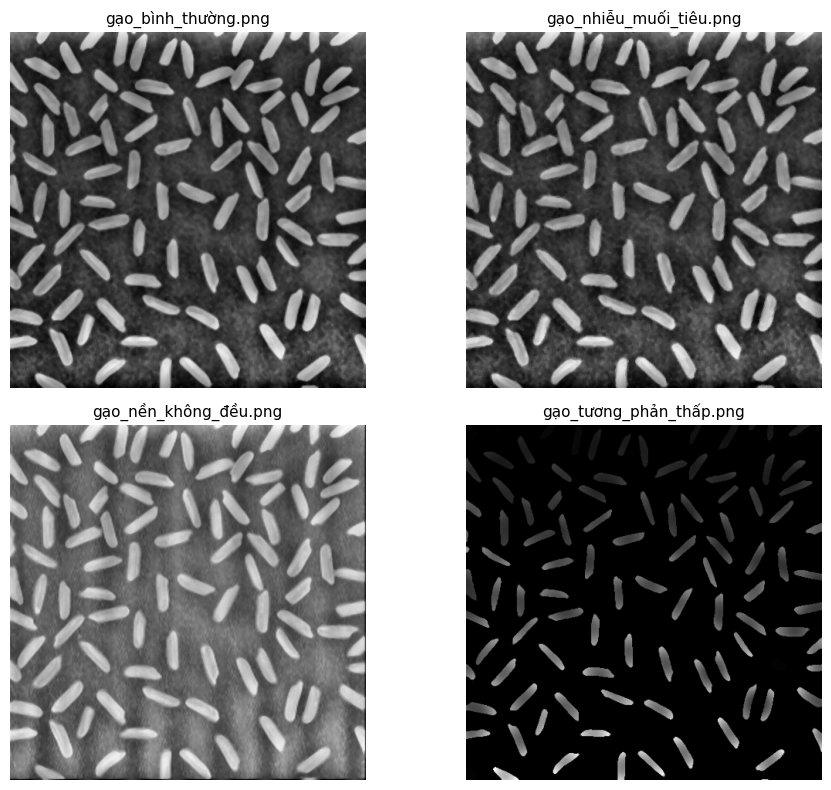

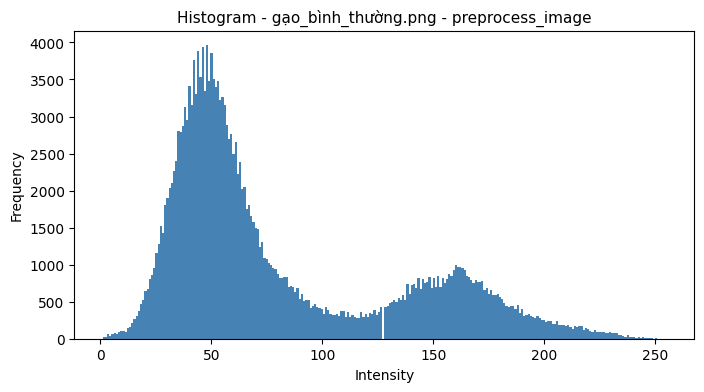

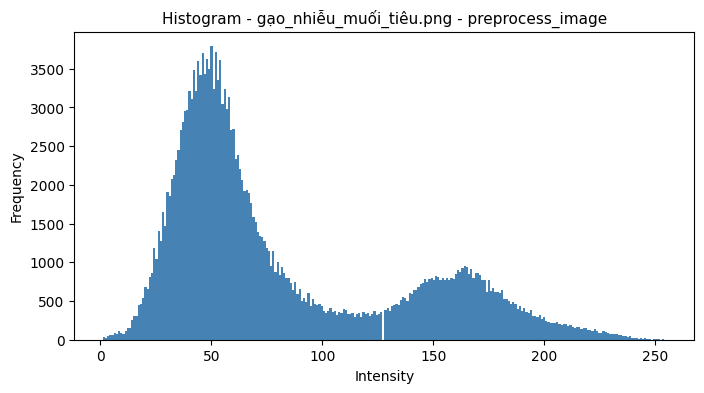

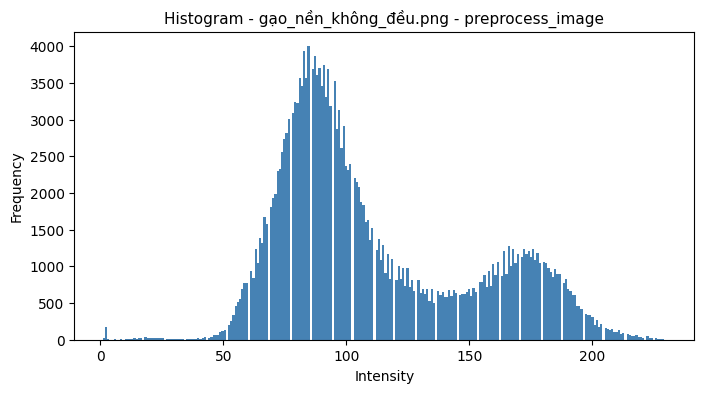

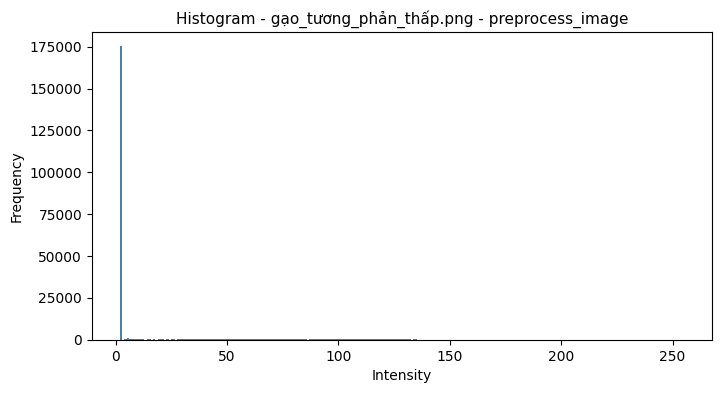

In [44]:
preprocess_steps_by_image = {}
preprocess_rows = []
preprocess_step_names = [
    "input_image",
    "to_grayscale",
    "denoise_image",
    "correct_illumination_fourier",
    "suppress_stripes_fourier",
    "correct_illumination",
    "enhance_contrast",
    "preprocess_image",
]

print("Pipeline tiền xử lý: median -> Fourier homomorphic -> Fourier notch -> CLAHE")
for image_name, image in input_images:
    gray = to_grayscale(image)
    denoised = denoise_image(gray, CONFIG.median_kernel_size)
    fourier_corrected = correct_illumination_fourier(
        denoised,
        CONFIG.fourier_cutoff,
        CONFIG.fourier_low_gain,
        CONFIG.fourier_high_gain,
    )
    stripe_suppressed = suppress_stripes_fourier(
        fourier_corrected,
        CONFIG.fourier_stripe_min_frequency,
        CONFIG.fourier_stripe_max_frequency,
        CONFIG.fourier_stripe_top_k,
        CONFIG.fourier_stripe_radius,
        CONFIG.fourier_stripe_strength,
    )
    corrected = correct_illumination(denoised, CONFIG)
    enhanced = enhance_contrast(corrected, CONFIG)
    preprocessed = preprocess_image(image, CONFIG)

    preprocess_steps_by_image[image_name] = {
        "input_image": image,
        "to_grayscale": gray,
        "denoise_image": denoised,
        "correct_illumination_fourier": fourier_corrected,
        "suppress_stripes_fourier": stripe_suppressed,
        "correct_illumination": corrected,
        "enhance_contrast": enhanced,
        "preprocess_image": preprocessed,
    }

    for step_name in preprocess_step_names:
        row = image_summary(f"{image_name} | {step_name}", preprocess_steps_by_image[image_name][step_name])
        row["image_name"] = image_name
        row["step"] = step_name
        preprocess_rows.append(row)

    print(
        image_name,
        "correct_illumination equals Fourier + notch:",
        bool(np.array_equal(corrected, stripe_suppressed)),
    )
    print(
        image_name,
        "preprocess_image equals step-by-step enhanced:",
        bool(np.array_equal(preprocessed, enhanced)),
    )

preprocess_df = pd.DataFrame(preprocess_rows)
display(preprocess_df[["image_name", "step", "shape", "dtype", "min", "max", "mean", "std"]])

for step_name in preprocess_step_names:
    print(f"[{step_name}] toàn bộ ảnh")
    step_items = [
        (image_name, preprocess_steps_by_image[image_name][step_name])
        for image_name, _ in input_images
    ]
    show_images(step_items, cols=2)

for image_name, _ in input_images:
    show_histogram(
        f"Histogram - {image_name} - preprocess_image",
        preprocess_steps_by_image[image_name]["preprocess_image"],
    )


## 4. Phân đoạn hạt gạo

Các bước phân đoạn gọi từ `src/segment.py`. `threshold_grains` dùng Otsu với adaptive fallback tự động, sau đó `clean_mask` loại nhiễu nhỏ và làm sạch vùng hạt.


gạo_bình_thường.png segment_grains equals clean_mask(threshold_grains): True
gạo_nhiễu_muối_tiêu.png segment_grains equals clean_mask(threshold_grains): True
gạo_nền_không_đều.png segment_grains equals clean_mask(threshold_grains): True
gạo_tương_phản_thấp.png segment_grains equals clean_mask(threshold_grains): True


,image_name,step,foreground_pixels,foreground_ratio,connected_components
0,gạo_bình_thường.png,threshold_grains,57671,0.271366,131
1,gạo_bình_thường.png,clean_mask,57325,0.269738,97
2,gạo_bình_thường.png,segment_grains,57325,0.269738,97
3,gạo_nhiễu_muối_tiêu.png,threshold_grains,57689,0.271451,132
4,gạo_nhiễu_muối_tiêu.png,clean_mask,57266,0.269460,96
5,gạo_nhiễu_muối_tiêu.png,segment_grains,57266,0.269460,96
6,gạo_nền_không_đều.png,threshold_grains,60592,0.285111,193
7,gạo_nền_không_đều.png,clean_mask,59623,0.280551,99
8,gạo_nền_không_đều.png,segment_grains,59623,0.280551,99
9,gạo_tương_phản_thấp.png,threshold_grains,30408,0.143082,103


[threshold_grains] toàn bộ ảnh


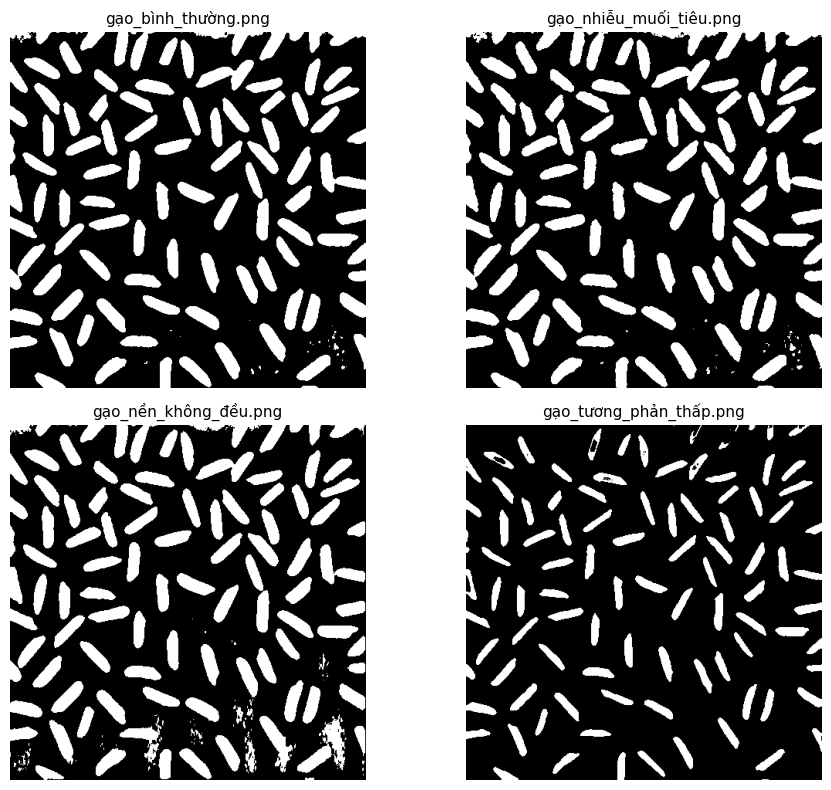

[clean_mask] toàn bộ ảnh


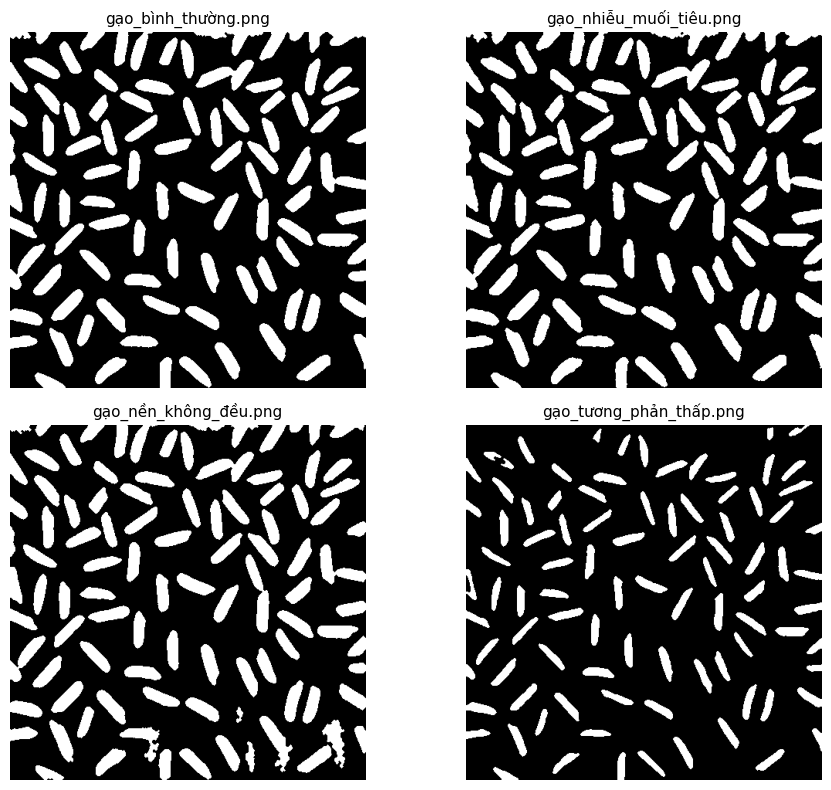

[segment_grains] toàn bộ ảnh


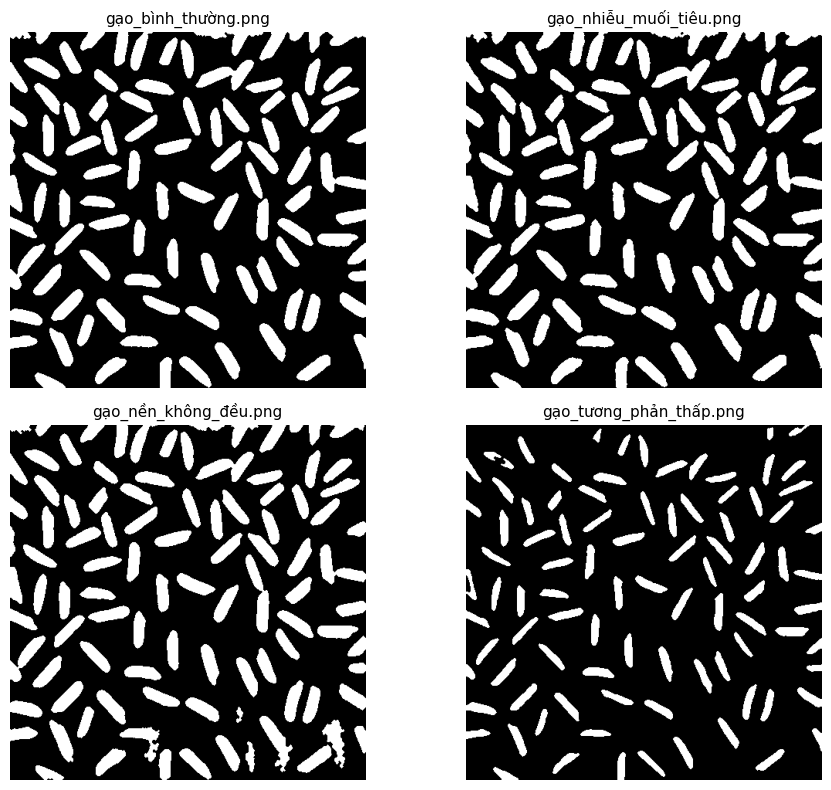

In [45]:
segmentation_steps_by_image = {}
segmentation_rows = []
segmentation_step_names = [
    "threshold_grains",
    "clean_mask",
    "segment_grains",
]

for image_name, _ in input_images:
    preprocessed = preprocess_steps_by_image[image_name]["preprocess_image"]
    raw_mask = threshold_grains(preprocessed, CONFIG)
    cleaned_mask = clean_mask(raw_mask, CONFIG)
    segmented_mask = segment_grains(preprocessed, CONFIG)

    segmentation_steps_by_image[image_name] = {
        "threshold_grains": raw_mask,
        "clean_mask": cleaned_mask,
        "segment_grains": segmented_mask,
    }

    print(
        image_name,
        "segment_grains equals clean_mask(threshold_grains):",
        bool(np.array_equal(segmented_mask, cleaned_mask)),
    )

    for step_name in segmentation_step_names:
        row = mask_summary(f"{image_name} | {step_name}", segmentation_steps_by_image[image_name][step_name])
        row["image_name"] = image_name
        row["step"] = step_name
        segmentation_rows.append(row)

segmentation_df = pd.DataFrame(segmentation_rows)
display(segmentation_df[["image_name", "step", "foreground_pixels", "foreground_ratio", "connected_components"]])

for step_name in segmentation_step_names:
    print(f"[{step_name}] toàn bộ ảnh")
    step_items = [
        (image_name, segmentation_steps_by_image[image_name][step_name])
        for image_name, _ in input_images
    ]
    show_images(step_items, cols=2)

## 5. Tách hạt dính nhau và đếm

Các bước watershed và lọc vùng gọi từ `src/watershed_count.py`. Kết quả cuối cùng được so sánh với hàm `separate_and_count` dùng trong script.


,image_name,step,label_count,labeled_pixels
0,gạo_bình_thường.png,watershed_separation,103,57325
1,gạo_bình_thường.png,filter_grain_regions,101,57111
2,gạo_nhiễu_muối_tiêu.png,watershed_separation,102,57266
3,gạo_nhiễu_muối_tiêu.png,filter_grain_regions,100,57046
4,gạo_nền_không_đều.png,watershed_separation,110,59623
5,gạo_nền_không_đều.png,filter_grain_regions,107,58939
6,gạo_tương_phản_thấp.png,watershed_separation,96,29948
7,gạo_tương_phản_thấp.png,filter_grain_regions,96,29948


,image_name,final_count,rejected_regions,rejected_by_filter_direct
0,gạo_bình_thường.png,101,2,2
1,gạo_nhiễu_muối_tiêu.png,100,2,2
2,gạo_nền_không_đều.png,107,3,3
3,gạo_tương_phản_thấp.png,96,0,0


[cleaned_mask] toàn bộ ảnh


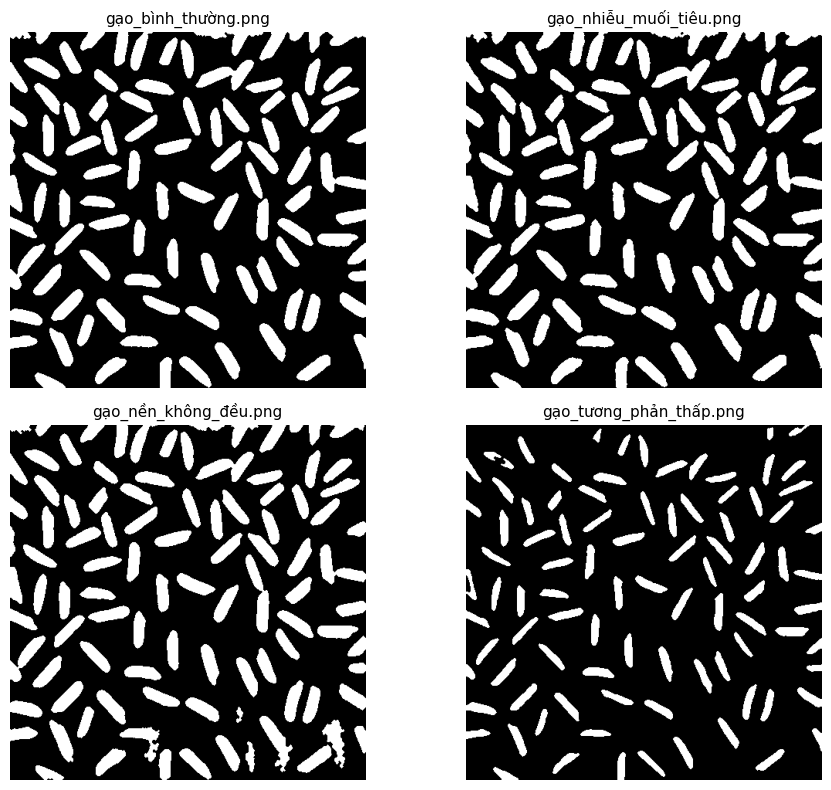

[watershed_labels] toàn bộ ảnh


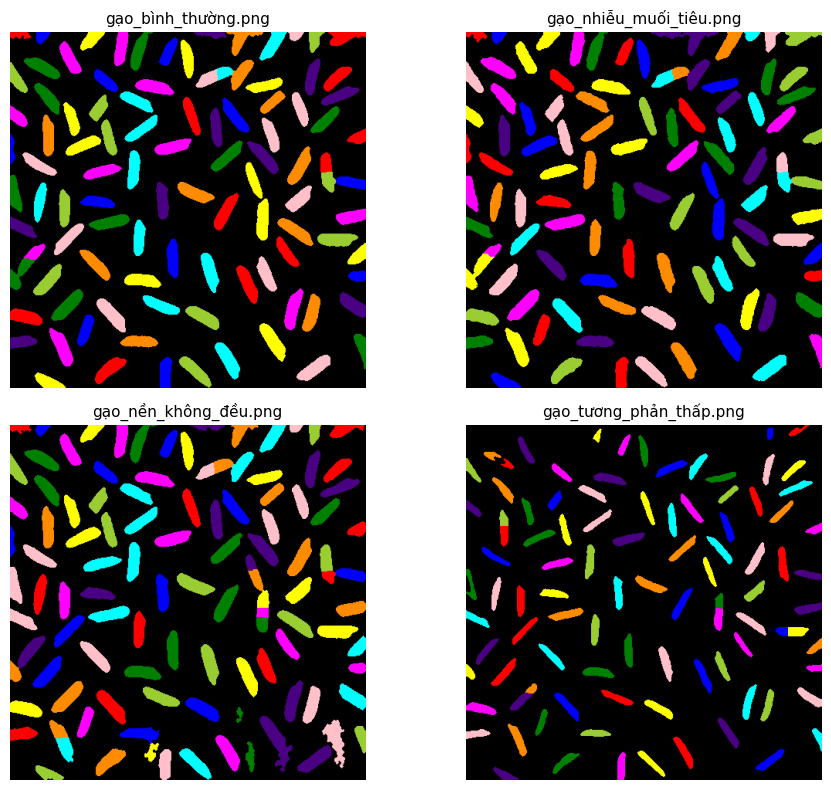

[filtered_labels] toàn bộ ảnh


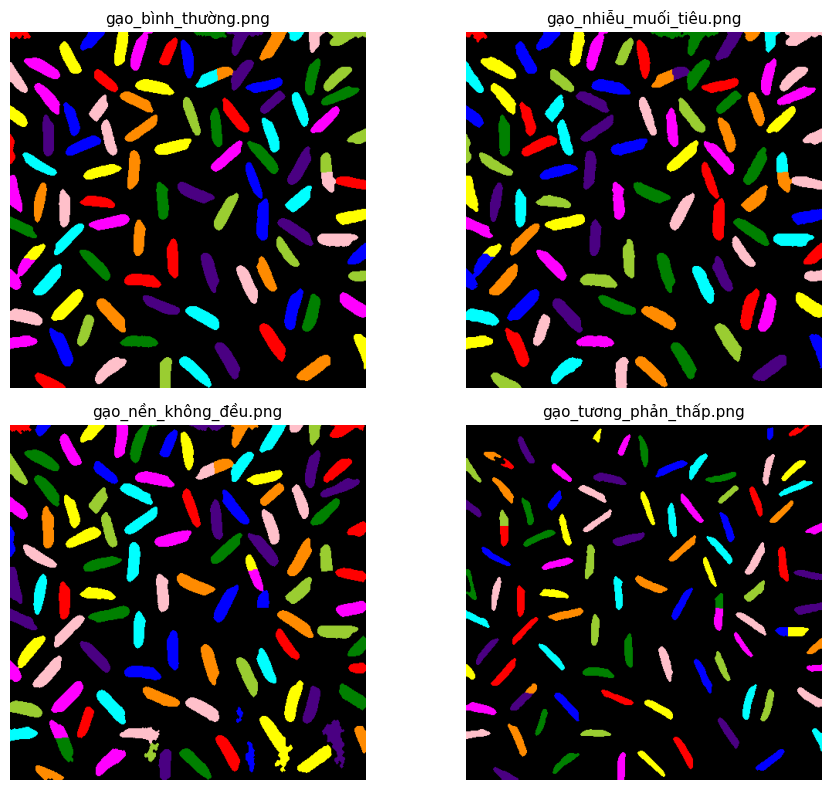

[contour_overlay] toàn bộ ảnh


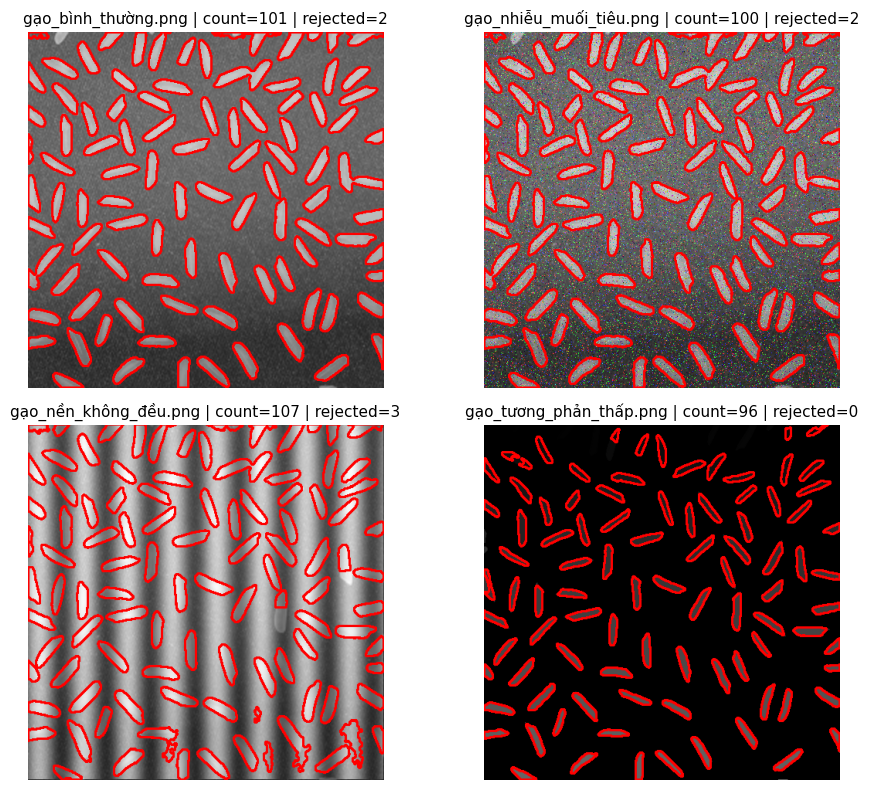

In [46]:
count_steps_by_image = {}
label_rows = []
count_rows = []
count_step_names = [
    "cleaned_mask",
    "watershed_labels",
    "filtered_labels",
    "contour_overlay",
]

for image_name, image in input_images:
    cleaned_mask = segmentation_steps_by_image[image_name]["clean_mask"]
    labels = watershed_separation(cleaned_mask, CONFIG)
    filtered_labels, rejected_regions = filter_grain_regions(labels, CONFIG)
    count_result = separate_and_count(image_name, cleaned_mask, CONFIG)
    overlay = contour_overlay(image, count_result.labels)

    count_steps_by_image[image_name] = {
        "cleaned_mask": cleaned_mask,
        "watershed_labels": labels,
        "filtered_labels": filtered_labels,
        "contour_overlay": overlay,
        "count_result": count_result,
        "rejected_regions": rejected_regions,
    }

    watershed_row = label_summary(f"{image_name} | watershed_separation", labels)
    watershed_row["image_name"] = image_name
    watershed_row["step"] = "watershed_separation"
    label_rows.append(watershed_row)

    filtered_row = label_summary(f"{image_name} | filter_grain_regions", filtered_labels)
    filtered_row["image_name"] = image_name
    filtered_row["step"] = "filter_grain_regions"
    label_rows.append(filtered_row)

    count_rows.append({
        "image_name": image_name,
        "final_count": count_result.count,
        "rejected_regions": count_result.rejected_regions,
        "rejected_by_filter_direct": rejected_regions,
    })

label_df = pd.DataFrame(label_rows)
count_df = pd.DataFrame(count_rows)
display(label_df[["image_name", "step", "label_count", "labeled_pixels"]])
display(count_df)

for step_name in count_step_names:
    print(f"[{step_name}] toàn bộ ảnh")
    step_items = []
    for image_name, _ in input_images:
        image = count_steps_by_image[image_name][step_name]
        if step_name in {"watershed_labels", "filtered_labels"}:
            image = color.label2rgb(image, bg_label=0)
        title = image_name
        if step_name == "contour_overlay":
            result = count_steps_by_image[image_name]["count_result"]
            title = f"{image_name} | count={result.count} | rejected={result.rejected_regions}"
        step_items.append((title, image))
    show_images(step_items, cols=2)

## 6. Chạy toàn bộ dataset

Cell này gọi `run_all_images(CONFIG)` từ `src/main.py`. Hàm này dùng cùng pipeline, cùng cấu hình đang được reload ở cell setup, lưu `output/results.csv` và ghi log local trong `logs/`.


In [47]:
batch_results = run_all_images(CONFIG)
results_df = pd.DataFrame([
    {
        "image_name": result.image_name,
        "count": result.count,
        "rejected_regions": result.rejected_regions,
    }
    for result in batch_results
])

display(results_df)
print("Saved:", OUTPUT_DIR / "results.csv")
print("Log updated:", LOG_DIR / "parameter_runs.md")

,image_name,count,rejected_regions
0,gạo_bình_thường.png,101,2
1,gạo_nhiễu_muối_tiêu.png,100,2
2,gạo_nền_không_đều.png,107,3
3,gạo_tương_phản_thấp.png,96,0


Saved: output\results.csv
Log updated: logs\parameter_runs.md


## 7. Kiểm tra contour overlay

Cell này hiển thị contour overlay cho từng ảnh để đánh giá trực quan. Khi đánh giá bắt buộc giữ nguyên `DEFAULT_CONFIG` cho toàn bộ ảnh, không chỉnh tham số riêng theo từng ảnh.


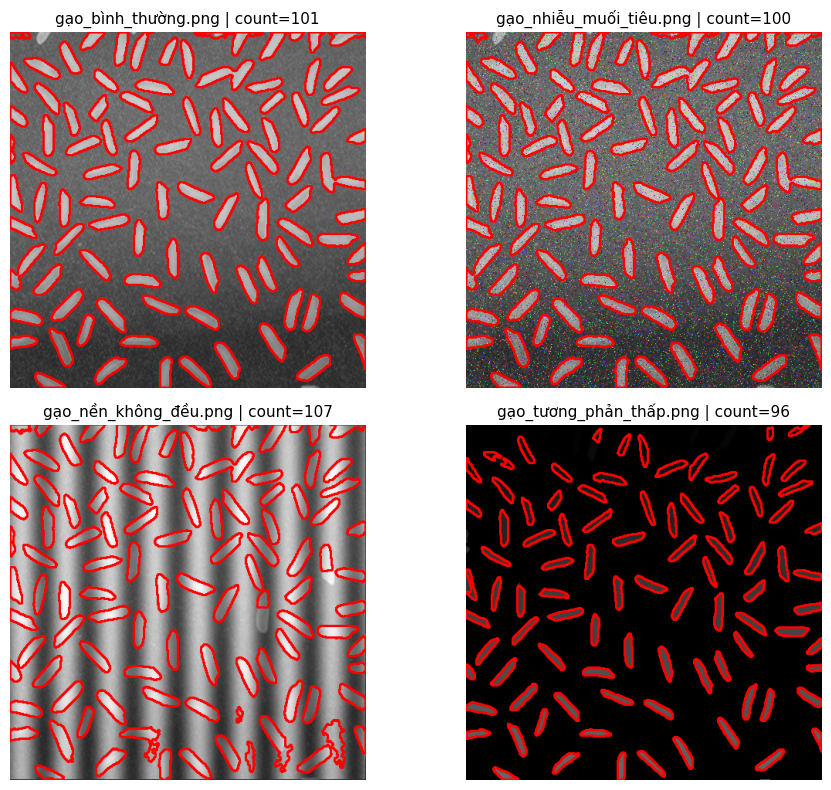

In [48]:
overlays = [
    (
        f"{image_name} | count={count_steps_by_image[image_name]['count_result'].count}",
        count_steps_by_image[image_name]["contour_overlay"],
    )
    for image_name, _ in input_images
]

show_images(overlays, cols=2)

## 8. Ghi chú

Notebook này không giữ bản sao tham số riêng. Muốn điều chỉnh kết quả, sửa một bộ tham số chung trong `src/config.py`, chạy lại toàn bộ ảnh, rồi xem log trong `logs/parameter_runs.md`.
